In [168]:
import pandas as pd
import os
import sys
from cycler import cycler
import argparse
from functools import reduce
import matplotlib.pyplot as plt


workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../")

import pyanalib.pandas_helpers as ph
import warnings
from pyanalib.split_df_helpers import *
from makedf.util import *
from analysis_village.gump.gump_cuts import *
from analysis_village.gump.plot_tools import *
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')

import warnings
warnings.filterwarnings('ignore')

In [128]:
def load_dent_dfs(loc):
    dfs = []
    pot = 0.0
    
    files = os.listdir(loc)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for f in tqdm(files, desc="Loading files"):
            all_dfs = load_dfs(loc+f, ['evt', 'hdr'])
            recodf = all_dfs['evt']
            pot += all_dfs['hdr'].pot.sum()
            dfs.append(recodf)
    
    df = pd.concat(dfs)
    print(len(df))
    extravarnames = [
        "mu_costh",
        "mu_phi",
        "p_costh",
        "p_phi",
    ]
    
    
    extravars = [
        lambda d: np.cos(d.mu_dir_z),
        lambda d: np.arctan2(d.mu_dir_x, d.mu_dir_y)*180/np.pi,
        lambda d: np.cos(d.p_dir_z),
        lambda d: np.arctan2(d.p_dir_x, d.p_dir_y)*180/np.pi,
    ]
    
    for v, vname in zip(extravars, extravarnames):
        df[vname] = v(df)

    return df, pot

In [165]:
from tqdm import tqdm
import gump_cuts as gc

def plot_hist(dfs, title_str='', output="output.png", phi_cut=False, gump_cuts=False, var='slc_vtx_x', labels=None, isdata=True, pots=None, remove_cosmics=False, only_cosmics=False):
    if not pots:
        pots = [1.0]*len(dfs)
        
    if not labels:
        labels = ['']*len(dfs)
        
    for dfi, df in enumerate(dfs):
        dfs[dfi]['Run'] = 1
        if gump_cuts:
            dfs[dfi] = df[gc.all_cuts(df)]
            df = dfs[dfi]
        
        if phi_cut:
            dfs[dfi] = df[(df.mu_phi < -50.) & (df.mu_phi > -120.)]
            df = dfs[dfi]

        if remove_cosmics:
            dfs[dfi] = df[df.is_cosmic == False]
            df = dfs[dfi]
        elif only_cosmics:
            dfs[dfi] = df[df.is_cosmic == True]
            df = dfs[dfi]

    b = np.linspace(-200., 200., 20)
    centers = bin_centers(b)

    if isdata:
        # Handle the data first
        loc_data_df = dfs[0]
        data_counts, bin_edges = np.histogram(loc_data_df[var], bins=b)
        data_total = len(loc_data_df)
            
        n = data_counts / data_total
        data_err = np.sqrt(data_counts) / data_total
        plt.errorbar(centers, n, yerr=data_err,  marker='o', linestyle='none', label=labels[0])
        normabs=True
    else:
        normabs=False
    if isdata:
        dfs = dfs[1:]
        labels = labels[1:]
        
    for loc_mc_df, l, pot in zip(dfs, labels, pots):
        mc_counts, bin_edges = np.histogram(loc_mc_df[var], bins=b)
        if normabs:
            mc_total = len(loc_mc_df)
        else:
            mc_total = 1.0
        # mc_norm = mc_counts / mc_total
        # mc_err = np.sqrt(mc_counts) / mc_total

        plt.hist(loc_mc_df[var], bins=b, weights=np.ones_like(loc_mc_df[var])*pots[0]/pot/mc_total, 
                 histtype='step', label=l)

        # mc_norm_ext = np.append(mc_norm, mc_norm[-1])
        # mc_err_ext = np.append(mc_err, mc_err[-1])

        # plt.fill_between(bin_edges, 
        #                  mc_norm_ext - mc_err_ext, 
        #                  mc_norm_ext + mc_err_ext, 
        #                  step='post', # 'post' ensures the height stays constant across the bin
        #                   alpha=0.2, label='MC Stat. Unc.')

    if phi_cut:
        title_str += '\n$\phi \in [-120, -50]$'

    if gump_cuts:
        title_str += '\nGUMP Selection'

    if remove_cosmics:
        title_str += '\nCosmics Removed'
    elif only_cosmics:
        title_str += '\nOnly Cosmics'
        
    plt.title(f'{title_str}')
    plt.legend()
    if normabs:
        plt.ylim(0., 0.2)

    if isdata:
        plt.ylabel("Events (Area Norm.)")
    else:
        plt.ylabel("Events")
        
    plt.xlabel(var)
    plt.savefig(output)
    plt.show()
    plt.clf()

In [139]:
prefix = "/exp/sbnd/data/users/nrowe/dent/"
emperical_df, emperical_pot = load_dent_dfs(prefix+"emperical_dent/")
theory_df, theory_pot = load_dent_dfs(prefix+"theory_dent/")
data_df, _ = load_dent_dfs(prefix+"SBND_SpringDevBNBData/")
cv_df, cv_pot = load_dent_dfs(prefix+"cv/")

Loading files: 100%|██████████| 100/100 [00:04<00:00, 23.28it/s]


284444


Loading files: 100%|██████████| 99/99 [00:05<00:00, 19.66it/s]


1713251


Loading files: 100%|██████████| 20/20 [00:00<00:00, 20.10it/s]


448167


Loading files: 100%|██████████| 5/5 [01:02<00:00, 12.54s/it]


14224997


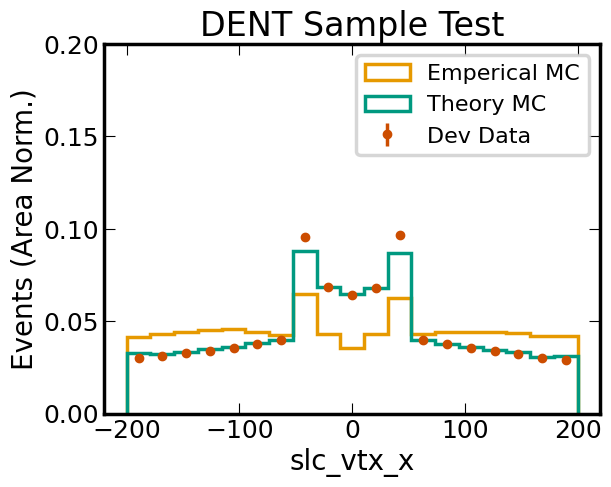

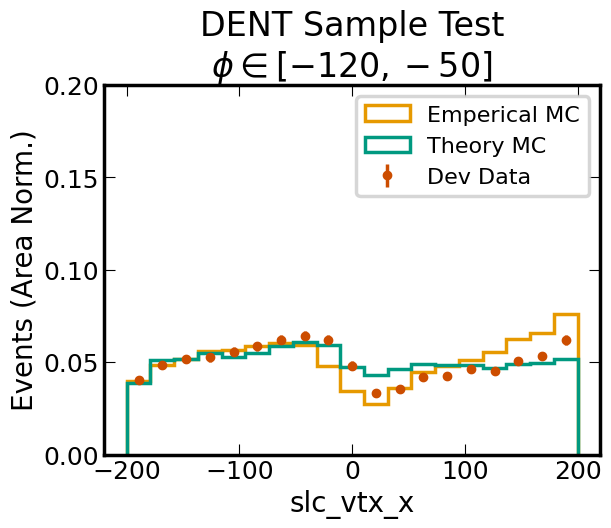

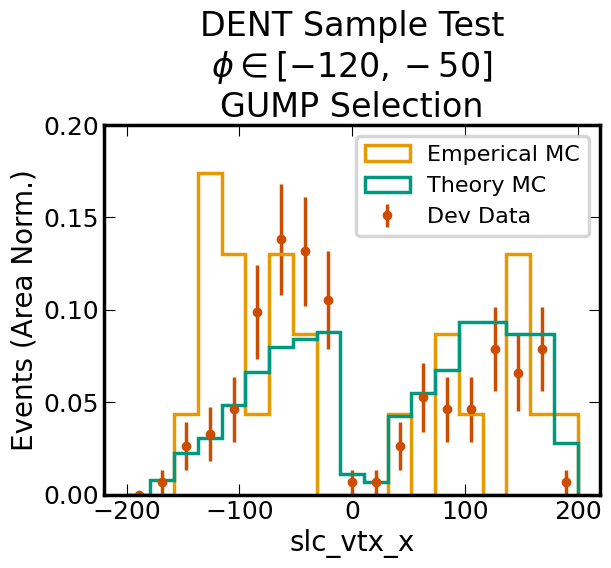

<Figure size 640x480 with 0 Axes>

In [169]:
plot_hist([data_df, emperical_df, theory_df], labels=['Dev Data','Emperical MC','Theory MC'], title_str='DENT Sample Test')
plot_hist([data_df, emperical_df, theory_df], labels=['Dev Data','Emperical MC','Theory MC'], phi_cut=True, title_str='DENT Sample Test')
plot_hist([data_df, emperical_df, theory_df], labels=['Dev Data','Emperical MC','Theory MC'], phi_cut=True, gump_cuts=True, title_str='DENT Sample Test')

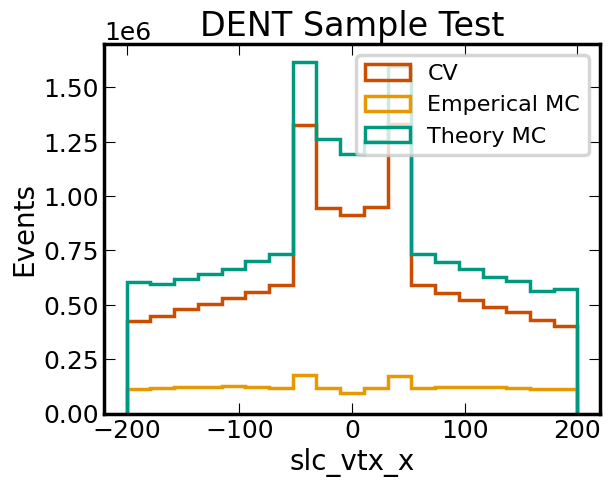

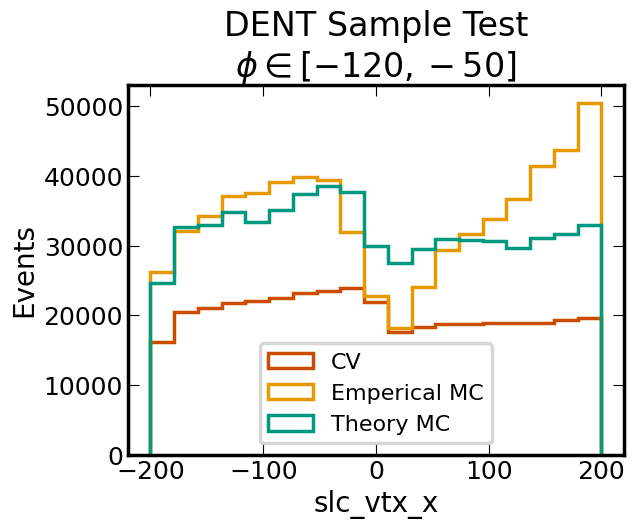

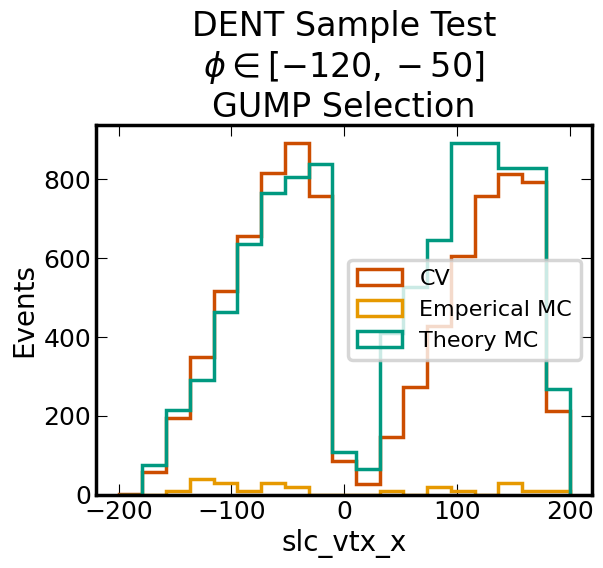

<Figure size 640x480 with 0 Axes>

In [170]:
plot_hist([cv_df, emperical_df, theory_df], labels=['CV', 'Emperical MC','Theory MC'], phi_cut=False, gump_cuts=False, title_str='DENT Sample Test', isdata=False, pots=[cv_pot, emperical_pot, theory_pot])
plot_hist([cv_df, emperical_df, theory_df], labels=['CV', 'Emperical MC','Theory MC'], phi_cut=True, gump_cuts=False, title_str='DENT Sample Test', isdata=False, pots=[cv_pot, emperical_pot, theory_pot])
plot_hist([cv_df, emperical_df, theory_df], labels=['CV', 'Emperical MC','Theory MC'], phi_cut=True, gump_cuts=True, title_str='DENT Sample Test', isdata=False, pots=[cv_pot, emperical_pot, theory_pot])

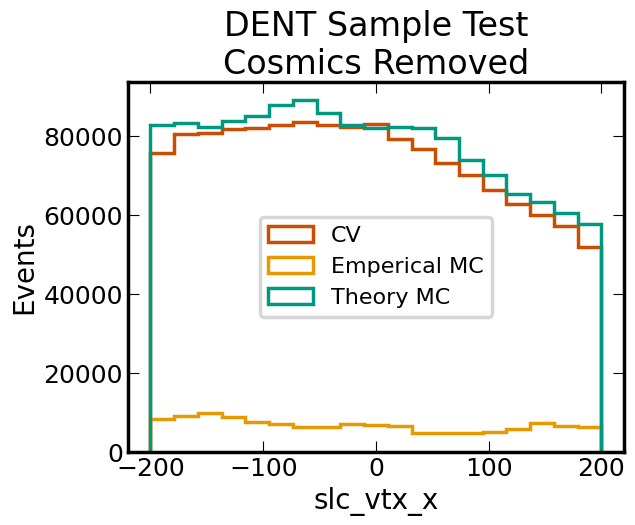

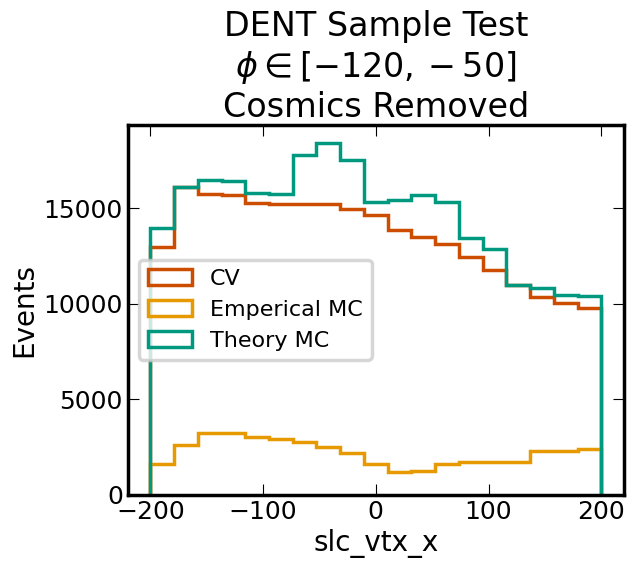

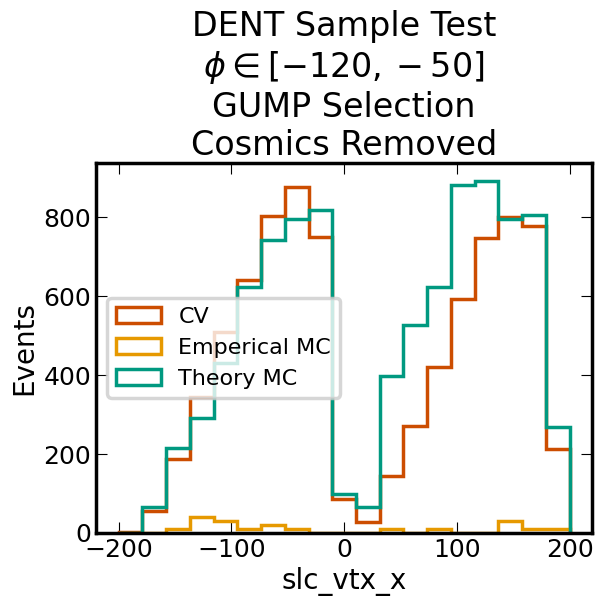

<Figure size 640x480 with 0 Axes>

In [171]:
plot_hist([cv_df, emperical_df, theory_df], labels=['CV', 'Emperical MC','Theory MC'], phi_cut=False, gump_cuts=False, title_str='DENT Sample Test', isdata=False, pots=[cv_pot, emperical_pot, theory_pot], remove_cosmics=True)
plot_hist([cv_df, emperical_df, theory_df], labels=['CV', 'Emperical MC','Theory MC'], phi_cut=True, gump_cuts=False, title_str='DENT Sample Test', isdata=False, pots=[cv_pot, emperical_pot, theory_pot], remove_cosmics=True)
plot_hist([cv_df, emperical_df, theory_df], labels=['CV', 'Emperical MC','Theory MC'], phi_cut=True, gump_cuts=True, title_str='DENT Sample Test', isdata=False, pots=[cv_pot, emperical_pot, theory_pot], remove_cosmics=True)

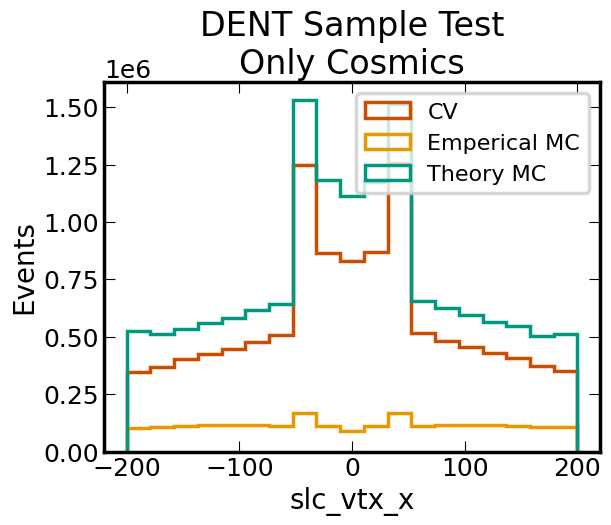

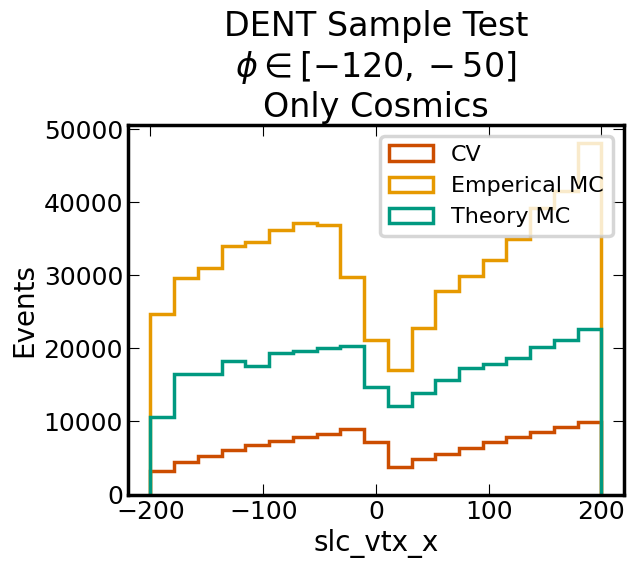

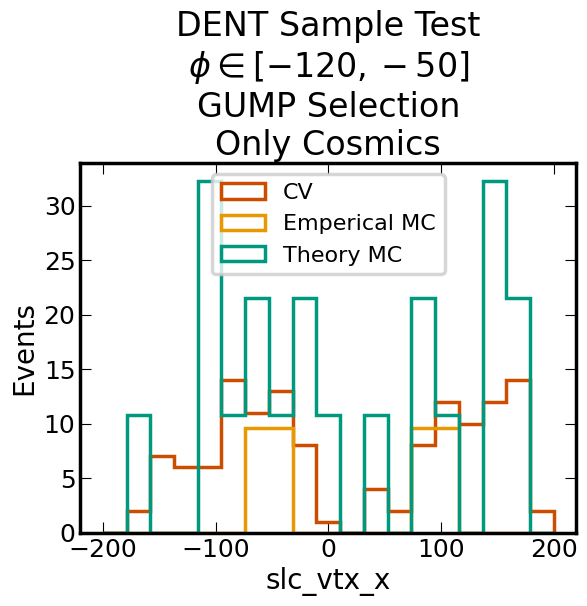

<Figure size 640x480 with 0 Axes>

In [172]:
plot_hist([cv_df, emperical_df, theory_df], labels=['CV', 'Emperical MC','Theory MC'], phi_cut=False, gump_cuts=False, title_str='DENT Sample Test', isdata=False, pots=[cv_pot, emperical_pot, theory_pot], only_cosmics=True)
plot_hist([cv_df, emperical_df, theory_df], labels=['CV', 'Emperical MC','Theory MC'], phi_cut=True, gump_cuts=False, title_str='DENT Sample Test', isdata=False, pots=[cv_pot, emperical_pot, theory_pot], only_cosmics=True)
plot_hist([cv_df, emperical_df, theory_df], labels=['CV', 'Emperical MC','Theory MC'], phi_cut=True, gump_cuts=True, title_str='DENT Sample Test', isdata=False, pots=[cv_pot, emperical_pot, theory_pot], only_cosmics=True)